In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [ ]:
import sys
sys.path.append("../")

In [ ]:
import os
os.environ["CC"] = "/usr/bin/clang"
os.environ["CXX"] = "/usr/bin/clang++"

In [ ]:
from cmdstanpy import cmdstan_path, set_cmdstan_path

set_cmdstan_path()
print(cmdstan_path()) 

In [ ]:
## Get past evaluation for grid and data scaling

fp = "./Data_LA-UR-25-31736/Eval_MvUncCf252PFNS_AfterAIACHNEKnowledgePointwise_Upd20250908.dat"

eval = pd.read_csv(fp, sep=r"\s+", skiprows=2, header=None, names=['Eout', 'val', 'rel_unc'])
xgrid_eval = eval.Eout.values

xgrid_eval

In [ ]:
from processing import compile_data_dicts
from processing.AIACHNE import read_aiachne_json, compile_nd_dfs
from utils.functions import get_scale_factor

basepath="./Data_LA-UR-25-31736"

def get_feature(data):
    try:
        return data['attributes']['NeutronDetector']['Type']
    except:
        return data['attributes']['NeutronDetector'][0]['Type']

data_dict_list = []
for fp in os.listdir(basepath):

    if not fp.endswith(".json"):
        continue

    print(fp)
    
    data_dict = read_aiachne_json(os.path.join(basepath, fp), bias_category = get_feature)# "Expt_Name") 

    # normalize data to past evaluation
    ds = get_scale_factor(data_dict['X'], data_dict['expt_value'], eval.Eout.values, eval.val.values)
    data_dict['expt_value'] *= ds

    data_dict_list.append(data_dict)

data_dict_compiled = compile_data_dicts(data_dict_list) #, xminmax=[1e-5,12])

In [ ]:
print(data_dict_compiled.keys())
A = data_dict_compiled['bias_label']

In [ ]:
np.unique(A)

In [ ]:
from sparse_bias import BiasModel, BasisModel 
from processing  import convert_to_stan_data

############
#
# Build relevant Basis functions
#
basis_obj = BasisModel(data_dict_compiled,
                       mean_basis_type = "interpolation",
                       bias_basis_type = "gaussian")

minX = np.log10( min(xgrid_eval) - 1e-4 )
maxX = np.log10( max(xgrid_eval) + 0.5e+1 )

basis_obj.generate_mean_bases(X_grid=xgrid_eval) #,centers=centers, widths=width)

# Gaussian bases for the bias - center and width parameters for bias gaussian functions
centers  = [
    np.linspace(minX, maxX, 100), 
    np.linspace(minX, maxX, 50),
    np.linspace(minX, maxX, 10)
]
widths   = [0.05, 0.15, 0.3]
basis_obj.generate_bias_bases(centers=centers, widths=widths) # note in docstring this is logarithm of energy


In [ ]:
### Visualize your bias terms 

plot_x = np.logspace(minX, maxX, 500)
B_s, B_m, B_l = basis_obj.get_plotable_bias_bases(plot_x)

gamma_s = np.ones((len(centers[0]),1))#*0
gamma_m = np.ones((len(centers[1]),1))
gamma_l = np.ones((len(centers[2]),1))

# gamma_s[7] = 0.5
delta_s = B_s @ gamma_s
delta_m = B_m @ gamma_m*0.5
delta_l = B_l @ gamma_l*0.5

plt.figure(figsize=(5,3))
plt.plot(plot_x, np.exp(delta_s))
plt.plot(plot_x, np.exp(delta_m))
plt.plot(plot_x, np.exp(delta_l))
# plt.xlim(1e-3, 12)

plt.xscale('log')


In [ ]:
############
#
# Build Sparse Bias Model
#
sbmod = BiasModel(basis_obj, 
                  model_name = "interpolation_horseshoe",
                  tau_scale=1.e-5) 

# fit
nsamples = 2500
sbmod.fit(n_warmup=2000, n_sample=nsamples, show_console=False) 

# Analysis

In [ ]:
from utils import analysis
import importlib
importlib.reload(analysis)

myanalysis = analysis.BiasAnalysis(sbmod)
myanalysis.compile_plotable_attributes(plot_x)

In [ ]:

print(f"ilevels: \t\t{[each for each in range(myanalysis.n_levels)]}")

count = myanalysis.count_terms_beyond_threshold_per_level(quantile = 0.7, threshold = 1e-5) # Pq or quantile level (quantile is the actual value)
print(f"Terms above threshold: \t{count}")

integrals = myanalysis.bias_L2norm_per_level()
print(f"Integral Bias: \t\t{np.round(integrals,4)}")

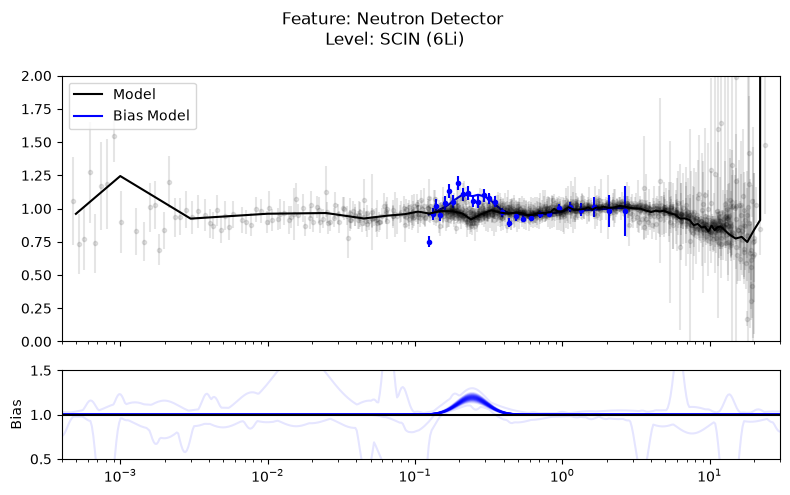

In [25]:
from utils.functions import maxwellian

def multiplication_function(x):
    return 1/maxwellian(1.42, x)

fig = myanalysis.get_ilevel_figure(6, feature='Neutron Detector', label_data=False, Nqs=50, multiplication_function=multiplication_function)

axes = fig.get_axes()

for ax in axes:
    ax.set_yscale('linear')
    ax.set_xlim(min(xgrid_eval) - 1e-4, max(xgrid_eval) + 0.5e+1 )

axes[0].set_ylim(0,2)
axes[1].set_ylim(0.5,1.5)
    
fig.tight_layout()